# One-pass rank-one KLT control: aggregated-particle NMS sweep

This notebook tests the control missing from the iterative masking experiment:
can one ordinary rank-one ALS/KLT fit on the **untouched raw tomogram** already
recover the different molecular classes if NMS is allowed to return the
aggregated number of molecular particles?

Every run uses identical geometry:

- particle diameter \(D=33\) voxels (the largest TomoTwin evaluation box,
  corresponding to 2df7);
- PSD patch size \(25\);
- Fredholm radius \(0.4D=13.2\) voxels;
- template side \(29\);
- NMS radius \(0.5D=16.5\) voxels;
- one global NMS call with `max_picks=51`, the total molecular GT count in the
  ROI.

Only the ACF support changes:

\[
d_{\max}\in\{7,9,12,15\}.
\]

Each run fits the detector from scratch, including both the initial noise fit
and the post-whitening particle RPSD fit. GT labels are used only to set the
aggregated count and perform the final global one-to-one evaluation.

In [1]:
from __future__ import annotations

import os
import time
from pathlib import Path

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tomotwin_iterative_masking_experiment import (
    CLASS_NAMES,
    FREDHOLM_RADIUS,
    NMS_RADIUS,
    PARTICLE_DIAMETER,
    PSD_PATCH_SIZE,
    TEMPLATE_SIDE,
    globally_match_by_class,
    load_roi_and_gt,
    make_detector,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

DATA_DIR = Path("data/tomotwin_2df7")
MAX_DISTANCES = [7, 9, 12, 15]
OUTPUT_CSV = Path("tomotwin_onepass_maxd_sweep.csv")

print("JAX:", jax.__version__)
print("JAX devices:", jax.devices())

JAX: 0.10.2
JAX devices: [CpuDevice(id=0)]


## Raw ROI and aggregated known count

In [2]:
raw_roi, gt_by_class, supported_gt_by_class = load_roi_and_gt(DATA_DIR)

count_table = pd.DataFrame({
    "class": CLASS_NAMES,
    "centers in ROI": [len(gt_by_class[label]) for label in CLASS_NAMES],
    "fully supported": [
        len(supported_gt_by_class[label]) for label in CLASS_NAMES
    ],
})
TOTAL_MOLECULAR_COUNT = int(count_table["centers in ROI"].sum())

settings = pd.Series({
    "raw ROI shape": raw_roi.shape,
    "particle diameter D": PARTICLE_DIAMETER,
    "PSD patch size": PSD_PATCH_SIZE,
    "Fredholm radius": FREDHOLM_RADIUS,
    "template side": TEMPLATE_SIDE,
    "NMS radius": NMS_RADIUS,
    "aggregated NMS max_picks": TOTAL_MOLECULAR_COUNT,
    "max_d sweep": tuple(MAX_DISTANCES),
})

display(settings.to_frame("value"))
display(count_table)
assert TOTAL_MOLECULAR_COUNT == 51

,value
raw ROI shape,"(128, 128, 128)"
particle diameter D,33
PSD patch size,25
Fredholm radius,13.2
template side,29
NMS radius,16.5
aggregated NMS max_picks,51
max_d sweep,"(7, 9, 12, 15)"


,class,centers in ROI,fully supported
0,1avo,8,5
1,1e9r,5,2
2,1fpy,4,1
3,1fzg,9,5
4,1jz8,4,0
5,1oao,9,1
6,2df7,12,7


## Run four independent one-pass detectors

For each `max_d`, a new detector is constructed from the untouched raw ROI.
The detector runs its complete two-pass spectral procedure and then makes one
NMS call with a maximum of 51 peaks. The returned peaks are globally matched
one-to-one to all molecular GT centers. The tolerance for a GT instance remains
half of its own class diameter.

In [3]:
result_tables = {}
aggregate_rows = []
picked_coordinates = {}

for max_distance in MAX_DISTANCES:
    print("=" * 72)
    print(
        f"Running untouched one-pass detector: max_d={max_distance}, "
        f"max_picks={TOTAL_MOLECULAR_COUNT}"
    )
    start = time.perf_counter()
    detector = make_detector(
        raw_roi,
        max_distance=max_distance,
        num_particles=TOTAL_MOLECULAR_COUNT,
    )
    returned_count, picks = detector.process_tomogram()
    elapsed = time.perf_counter() - start
    per_class, unmatched = globally_match_by_class(picks, gt_by_class)
    per_class.insert(0, "max_d", max_distance)
    result_tables[max_distance] = per_class
    picked_coordinates[max_distance] = picks

    matched = int(per_class["matched"].sum())
    aggregate_rows.append({
        "max_d": max_distance,
        "requested picks": TOTAL_MOLECULAR_COUNT,
        "returned picks": returned_count,
        "matched": matched,
        "unmatched": unmatched,
        "micro recall": matched / TOTAL_MOLECULAR_COUNT,
        "pick precision": matched / returned_count if returned_count else np.nan,
        "classes with >=1 match": int((per_class["matched"] > 0).sum()),
        "elapsed seconds": elapsed,
        "score maximum": float(np.max(detector.score_mat)),
    })
    print(
        f"Finished in {elapsed:.1f} s: matched={matched}, "
        f"unmatched={unmatched}, classes represented="
        f"{int((per_class['matched'] > 0).sum())}/7"
    )

aggregate_results = pd.DataFrame(aggregate_rows)
per_class_results = pd.concat(result_tables.values(), ignore_index=True)
per_class_results.to_csv(OUTPUT_CSV, index=False)

display(aggregate_results.round(4))
print(f"Saved per-class results to {OUTPUT_CSV.resolve()}")

Running untouched one-pass detector: max_d=7, max_picks=51


Finished in 9.5 s: matched=36, unmatched=15, classes represented=7/7
Running untouched one-pass detector: max_d=9, max_picks=51


Finished in 7.5 s: matched=36, unmatched=15, classes represented=7/7
Running untouched one-pass detector: max_d=12, max_picks=51


Finished in 7.4 s: matched=35, unmatched=16, classes represented=7/7
Running untouched one-pass detector: max_d=15, max_picks=51


Finished in 6.0 s: matched=31, unmatched=20, classes represented=7/7


,max_d,requested picks,returned picks,matched,unmatched,micro recall,pick precision,classes with >=1 match,elapsed seconds,score maximum
0,7,51,51,36,15,0.7059,0.7059,7,9.5272,419040.7188
1,9,51,51,36,15,0.7059,0.7059,7,7.5381,422981.4375
2,12,51,51,35,16,0.6863,0.6863,7,7.3889,403179.4688
3,15,51,51,31,20,0.6078,0.6078,7,5.9928,328274.7188


Saved per-class results to /Users/moshemaymon/Documents/thesis/tomotwin_onepass_maxd_sweep.csv


## Per-class counts and recall

In [4]:
matched_pivot = (
    per_class_results
    .pivot(index="max_d", columns="class", values="matched")
    .reindex(index=MAX_DISTANCES, columns=CLASS_NAMES)
)
recall_pivot = (
    per_class_results
    .pivot(index="max_d", columns="class", values="recall")
    .reindex(index=MAX_DISTANCES, columns=CLASS_NAMES)
)

print("Matched particles by class")
display(matched_pivot)
print("Recall by class")
display(recall_pivot.round(3))

Matched particles by class


class,1avo,1e9r,1fpy,1fzg,1jz8,1oao,2df7
max_d,,,,,,,
7,4,3,3,6,2,6,12
9,4,3,3,6,2,6,12
12,5,2,2,6,3,5,12
15,2,2,2,5,3,5,12


Recall by class


class,1avo,1e9r,1fpy,1fzg,1jz8,1oao,2df7
max_d,,,,,,,
7,0.500,0.6,0.75,0.667,0.50,0.667,1.0
9,0.500,0.6,0.75,0.667,0.50,0.667,1.0
12,0.625,0.4,0.50,0.667,0.75,0.556,1.0
15,0.250,0.4,0.50,0.556,0.75,0.556,1.0


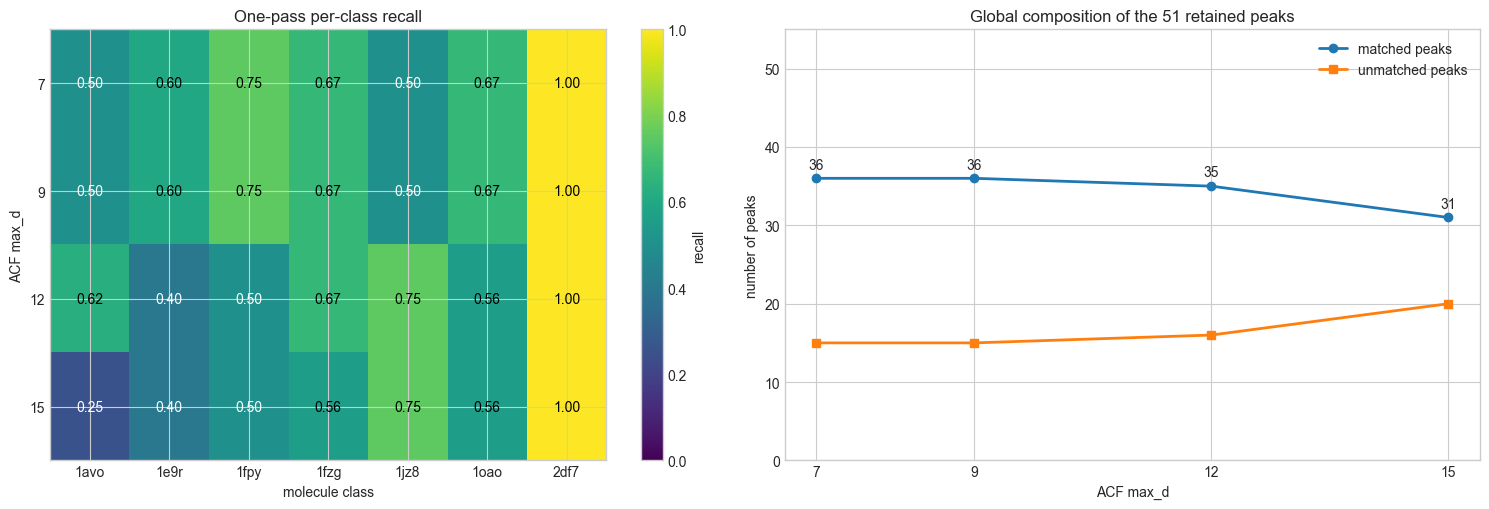

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

image = axes[0].imshow(
    recall_pivot.to_numpy(),
    vmin=0,
    vmax=1,
    cmap="viridis",
    aspect="auto",
)
for row in range(len(MAX_DISTANCES)):
    for column in range(len(CLASS_NAMES)):
        value = recall_pivot.iloc[row, column]
        axes[0].text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value < 0.55 else "black",
        )
axes[0].set_xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)
axes[0].set_yticks(np.arange(len(MAX_DISTANCES)), MAX_DISTANCES)
axes[0].set(
    title="One-pass per-class recall",
    xlabel="molecule class",
    ylabel="ACF max_d",
)
fig.colorbar(image, ax=axes[0], label="recall")

x = aggregate_results["max_d"].to_numpy()
axes[1].plot(
    x,
    aggregate_results["matched"],
    marker="o",
    linewidth=2,
    label="matched peaks",
)
axes[1].plot(
    x,
    aggregate_results["unmatched"],
    marker="s",
    linewidth=2,
    label="unmatched peaks",
)
for _, row in aggregate_results.iterrows():
    axes[1].annotate(
        f"{int(row['matched'])}",
        (row["max_d"], row["matched"]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
    )
axes[1].set(
    title="Global composition of the 51 retained peaks",
    xlabel="ACF max_d",
    ylabel="number of peaks",
    xticks=MAX_DISTANCES,
    ylim=(0, TOTAL_MOLECULAR_COUNT + 4),
)
axes[1].legend()

plt.tight_layout()
plt.show()

## Composition of matched peaks

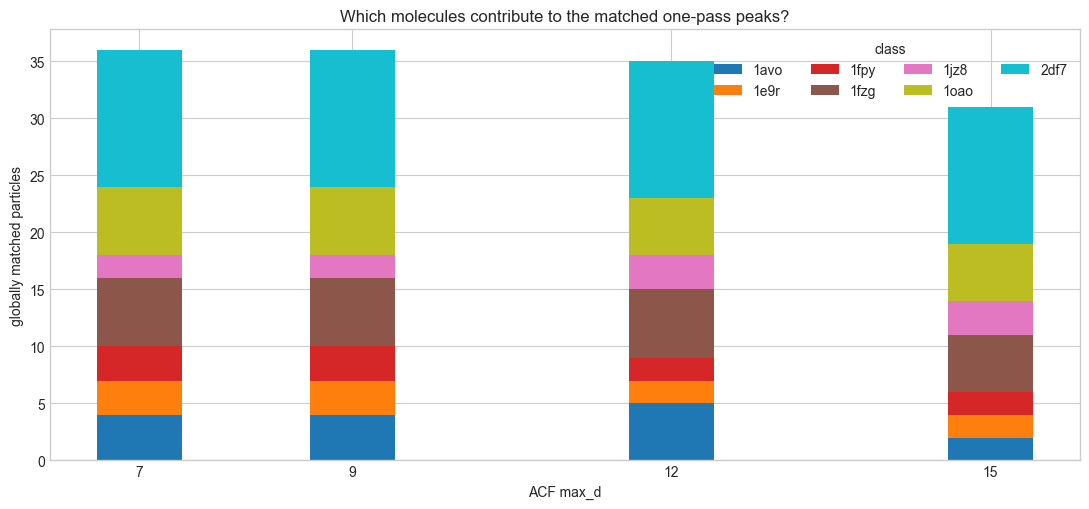

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.2))
bottom = np.zeros(len(MAX_DISTANCES))
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))
for color, label in zip(colors, CLASS_NAMES):
    values = matched_pivot[label].to_numpy()
    ax.bar(MAX_DISTANCES, values, bottom=bottom, label=label, color=color)
    bottom += values
ax.set(
    title="Which molecules contribute to the matched one-pass peaks?",
    xlabel="ACF max_d",
    ylabel="globally matched particles",
    xticks=MAX_DISTANCES,
)
ax.legend(title="class", ncol=4)
plt.tight_layout()
plt.show()

## Best one-pass setting and interpretation

Best max_d by globally matched count: 7


,class,available_gt,matched,recall,mean_distance_vox
0,1avo,8,4,0.500,2.574
1,1e9r,5,3,0.600,6.158
2,1fpy,4,3,0.750,4.666
3,1fzg,9,6,0.667,5.835
4,1jz8,4,2,0.500,2.835
5,1oao,9,6,0.667,5.099
6,2df7,12,12,1.000,4.260


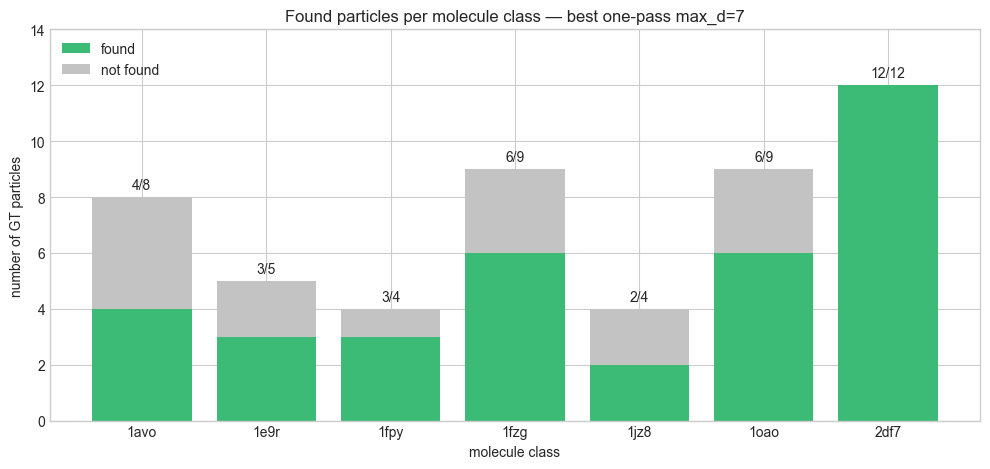

Contextual comparison (denominators differ because stage-1 masking removed GT centers):


,experiment,available GT,retained peaks,matched,matched / available
0,"one pass, untouched, max_d=7",51,51,36,0.706
1,"deflated stage 2, max_d=10",39,39,27,0.692



Guardrail: this is still a known-total-count control. It tests whether the untouched rank-one score ranking already covers multiple molecule classes when allowed 51 peaks; it does not supply class labels during fitting and does not define an unknown-count stopping threshold.


In [7]:
best_index = aggregate_results["matched"].idxmax()
best = aggregate_results.loc[best_index]
best_max_d = int(best["max_d"])
best_table = result_tables[best_max_d][
    ["class", "available_gt", "matched", "recall", "mean_distance_vox"]
]

print(f"Best max_d by globally matched count: {best_max_d}")
display(best_table.round(3))

found = best_table["matched"].to_numpy()
available = best_table["available_gt"].to_numpy()
missed = available - found
bar_positions = np.arange(len(CLASS_NAMES))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(
    bar_positions,
    found,
    label="found",
    color=plt.cm.viridis(0.68),
)
ax.bar(
    bar_positions,
    missed,
    bottom=found,
    label="not found",
    color=plt.cm.Greys(0.35),
)
for position, matched_count, total_count in zip(
    bar_positions, found, available
):
    ax.text(
        position,
        total_count + 0.18,
        f"{matched_count}/{total_count}",
        ha="center",
        va="bottom",
    )
ax.set_xticks(bar_positions, CLASS_NAMES)
ax.set(
    title=f"Found particles per molecule class — best one-pass max_d={best_max_d}",
    xlabel="molecule class",
    ylabel="number of GT particles",
    ylim=(0, available.max() + 2),
)
ax.legend()
plt.tight_layout()
plt.show()

deflated_csv = Path("tomotwin_iterative_masking_maxd12_then10.csv")
if deflated_csv.is_file():
    deflated = pd.read_csv(deflated_csv)
    deflated_matched = int(deflated["stage2_matched"].sum())
    deflated_available = int(deflated["stage2_available_gt"].sum())
    comparison = pd.DataFrame([
        {
            "experiment": f"one pass, untouched, max_d={best_max_d}",
            "available GT": TOTAL_MOLECULAR_COUNT,
            "retained peaks": TOTAL_MOLECULAR_COUNT,
            "matched": int(best["matched"]),
            "matched / available": best["matched"] / TOTAL_MOLECULAR_COUNT,
        },
        {
            "experiment": "deflated stage 2, max_d=10",
            "available GT": deflated_available,
            "retained peaks": deflated_available,
            "matched": deflated_matched,
            "matched / available": deflated_matched / deflated_available,
        },
    ])
    print(
        "Contextual comparison (denominators differ because stage-1 masking "
        "removed GT centers):"
    )
    display(comparison.round(3))

print(
    "\nGuardrail: this is still a known-total-count control. It tests whether "
    "the untouched rank-one score ranking already covers multiple molecule "
    "classes when allowed 51 peaks; it does not supply class labels during "
    "fitting and does not define an unknown-count stopping threshold."
)